In [1]:
%load_ext autoreload
%autoreload 2

## Example of switchable guidances with a V1 missile simulation
Notebook designed to show how switchable guidances are built and work.

In [45]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from mad.configs import EARTH_SETTINGS, V1, V1_guidance
from mad.objs import Planet, PlanetConfig
from mad.objs import CruiseMissile, CruiseMissileConfig
from mad.guidances import (CruiseWaypointGuidance, CruiseGuidanceConfig, GuidanceManager, NoGuidanceNoThrust, HoldPosition)
from mad.guidances.interrupt_guidances import (interrupt_at_t, interrupt_at_linear_distance_to_target)
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points, plot_ballistic_range_table_gamma
from mad.utils.ballistic_tables import load_ballistic_df

logger = SourceLogger()

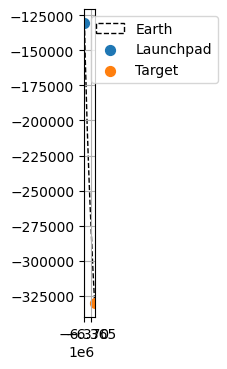

In [95]:
# FIrst, let's define the reference. planet erth, and 2 points on the surface. 
# One for launchpad and one for target, separated by 200 km.

EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 200
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")
plot_2D_planet_with_points(earth, points = [launchpad, target], display="arc");

From the V1 config files, we can see it has a maximum range of 250 km, it will be in range from launchpad to target.
Moreover, its max speed is around 170 m/s with a cruie altitude of 900 m.

In [96]:
V1, V1_guidance

({'name': 'V-1',
  'mass': 2150.0,
  'ref_radius': 0.3,
  'Cd': 0.5,
  'thrust_acc': 30.0,
  'max_range_m': 250000,
  'yield_kt': 0.0},
 {'max_speed_m_s': 177.77777777777777,
  'altitude_settling_time_s': 60.0,
  'cruise_altitude_m': 900.0})

The original V1 missile was set to nose-dive when in range of target, which stopped its motor.

In this case, we pre-calculated the ballistic table for the V1 missile.
We can see that at an altitude of 900 m and a speed of 170 m/s, it will still fly for around 2 - 3 km depending on gamma. 

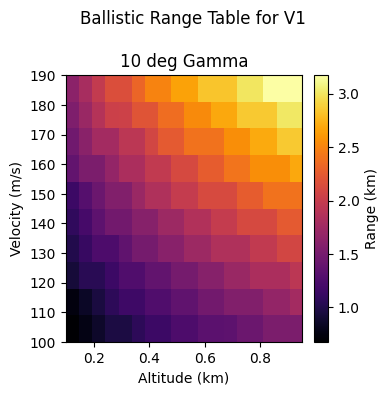

In [97]:
df = load_ballistic_df("V1")
plot_ballistic_range_table_gamma(df, selected_gamma=10, table_name="V1");

Let's define 3 guidances: one to wait for 5 s, then the main one that will fly from launchsite to target and finally a third one that will simply cut thrust and let the missile fall.

In [102]:
wait = HoldPosition(planet=earth, target=target, interrupt_fn=partial(interrupt_at_t, t=5))

fly_config = CruiseGuidanceConfig(waypoints=[launchpad, target], **V1_guidance)
fly = CruiseWaypointGuidance(planet=earth,
                            target=target, 
                            config=fly_config, 
                            interrupt_fn=partial(interrupt_at_linear_distance_to_target, 
                                                    reached_distance_m=3000) # 3000 m, estimation from the ballistic table
                            )

fall = NoGuidanceNoThrust(planet=earth, target=target)
guidance_manager = GuidanceManager(guidances=[wait, fly, fall])

V1_missile = CruiseMissile(position=launchpad.position.copy(), 
                           config=CruiseMissileConfig(**V1, guidance=guidance_manager))
    

21:41:33 | INFO     | Guidance     | CruiseWaypointGuidance: spline built over 2 waypoints (3 dense points), total arc length 200.0 km.


Now, if we run the simulation, we can see in the logs that the missile waited 5s to switch to cruise mode, then stopped its motor for a free fall hen getting close to the target.
It hits the ground and detonates 56 m away from the target.

In [ ]:
dt = 1.0
max_time = 5_000.0  # enough for 1000 km at ~250 m/s

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[V1_missile], # The only moving object is the missile
)

df = sim.results


21:43:36 | INFO     | Simulation   | 0.00s - Starting simulation.
21:43:36 | INFO     | Guidance     | 6.00s - Switching to guidance law 1: CruiseWaypointGuidance
21:43:37 | INFO     | Guidance     | 1043.00s - Switching to guidance law 2: NoGuidanceNoThrust
21:43:37 | INFO     | Missile      | 1057.00s - V-1 hit the ground at 56.87 m from target!
21:43:37 | INFO     | Missile      | 1057.00s - Warhead V-1 detonated with yield 0.00 kt.
21:43:37 | INFO     | Simulation   | 1057.00s - Simulation ended. Took 0.50 s of real time.


In [105]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

We can now plot the course of the missile, altitude and speed: 

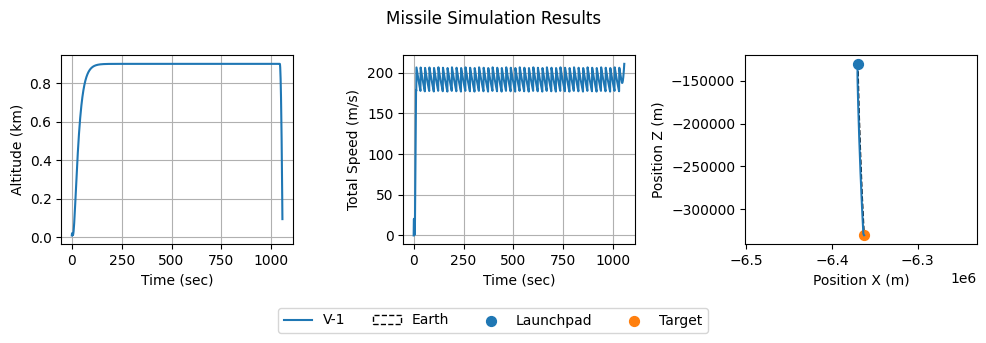

In [106]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(10, 3))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[2], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")


plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[2], display="arc")
ax[2].set_xlabel("Position X (m)")
ax[2].set_ylabel("Position Z (m)")
ax[2].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)